# CART Random Forest Cavitation Classifiers (Weighted Evaluation)
---
### Overview
This notebook implements separate **Audio** and **Piezo** CART Random Forest models (`criterion='gini'`, `max_depth=12`, `min_samples_leaf=5`, `ccp_alpha=0.001`).

Pipeline Steps:
1. **Missing Value Imputation**: Replacing NaNs with column means.
2. **Z-Score Normalization**: Standardizing feature columns via `StandardScaler`.
3. **CART Model Training**: Training regularized Audio and Piezo Random Forests.
4. **Weighted Test Set Evaluation**: Evaluating testing accuracy, weighted metrics (`average='weighted'`), and Seaborn confusion matrix heatmaps on `test_audio.csv` and `test_piezo.csv`.


## 1. Data Preprocessing (Imputation & Scaling)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Dataset paths
base_dir = os.path.dirname(os.path.abspath('')) if os.path.exists('../WBDB') else '.'
data_dir = os.path.join(base_dir, 'WBDB', 'Preprocessed')

df_tr_audio = pd.read_csv(os.path.join(data_dir, 'train_audio.csv'))
df_tr_piezo = pd.read_csv(os.path.join(data_dir, 'train_piezo.csv'))
df_ts_audio = pd.read_csv(os.path.join(data_dir, 'test_audio.csv'))
df_ts_piezo = pd.read_csv(os.path.join(data_dir, 'test_piezo.csv'))

audio_cols = [c for c in df_tr_audio.columns if c.startswith('audio_')]
piezo_cols = [c for c in df_tr_piezo.columns if c.startswith('piezo_')]

# Mean Imputation
imp_audio = SimpleImputer(strategy='mean')
imp_piezo = SimpleImputer(strategy='mean')

X_tr_audio_imp = imp_audio.fit_transform(df_tr_audio[audio_cols])
X_tr_piezo_imp = imp_piezo.fit_transform(df_tr_piezo[piezo_cols])
X_ts_audio_imp = imp_audio.transform(df_ts_audio[audio_cols])
X_ts_piezo_imp = imp_piezo.transform(df_ts_piezo[piezo_cols])

# Z-Score Scaling
scaler_audio = StandardScaler()
scaler_piezo = StandardScaler()

X_tr_audio_scaled = scaler_audio.fit_transform(X_tr_audio_imp)
X_tr_piezo_scaled = scaler_piezo.fit_transform(X_tr_piezo_imp)
X_ts_audio_scaled = scaler_audio.transform(X_ts_audio_imp)
X_ts_piezo_scaled = scaler_piezo.transform(X_ts_piezo_imp)

y_tr_audio = df_tr_audio['label'].values
y_tr_piezo = df_tr_piezo['label'].values
y_ts_audio = df_ts_audio['label'].values
y_ts_piezo = df_ts_piezo['label'].values

print("[+] Preprocessing (Mean Imputation + Z-Score Scaling) completed successfully.")


[+] Preprocessing (Mean Imputation + Z-Score Scaling) completed successfully.


## 2. Audio CART RF — Test Set Evaluation & Seaborn Heatmap


 AUDIO CART RF — TEST EVALUATION RESULTS (test_audio.csv)
Testing Accuracy              : 0.8944 (89.44%)
Testing Precision (Weighted)  : 0.8993
Testing Recall (Weighted)     : 0.8944
Testing F1 Score (Weighted)   : 0.8948
Testing ROC AUC (Weighted)    : 0.9795


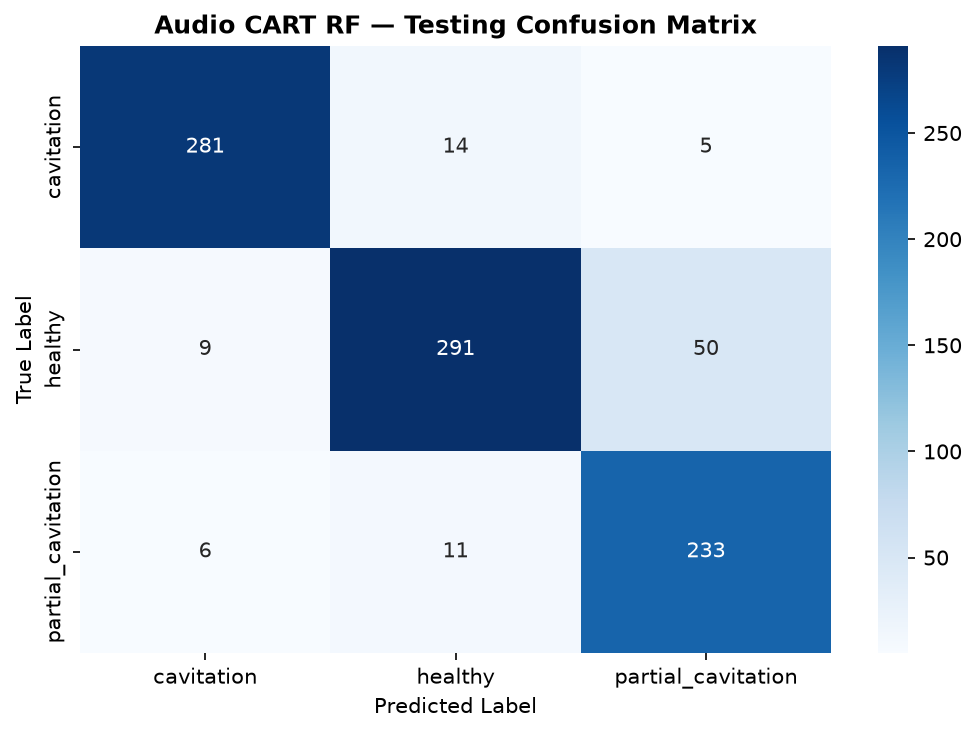

In [2]:
# Train Audio CART Random Forest
rf_audio = RandomForestClassifier(
    criterion="gini",
    max_depth=12,
    min_samples_leaf=5,
    ccp_alpha=0.001,
    n_estimators=100,
    random_state=42
)
rf_audio.fit(X_tr_audio_scaled, y_tr_audio)

classes_audio = list(rf_audio.classes_)

# Test predictions & metrics
ts_preds_audio = rf_audio.predict(X_ts_audio_scaled)
ts_probs_audio = rf_audio.predict_proba(X_ts_audio_scaled)

ts_acc_audio = accuracy_score(y_ts_audio, ts_preds_audio)
ts_prec_audio = precision_score(y_ts_audio, ts_preds_audio, average='weighted', zero_division=0)
ts_rec_audio = recall_score(y_ts_audio, ts_preds_audio, average='weighted', zero_division=0)
ts_f1_audio = f1_score(y_ts_audio, ts_preds_audio, average='weighted', zero_division=0)
ts_auc_audio = roc_auc_score(y_ts_audio, ts_probs_audio, multi_class='ovr', average='weighted')
cm_ts_audio = confusion_matrix(y_ts_audio, ts_preds_audio, labels=classes_audio)

print("=" * 60)
print(" AUDIO CART RF — TEST EVALUATION RESULTS (test_audio.csv)")
print("=" * 60)
print(f"Testing Accuracy              : {ts_acc_audio:.4f} ({ts_acc_audio*100:.2f}%)")
print(f"Testing Precision (Weighted)  : {ts_prec_audio:.4f}")
print(f"Testing Recall (Weighted)     : {ts_rec_audio:.4f}")
print(f"Testing F1 Score (Weighted)   : {ts_f1_audio:.4f}")
print(f"Testing ROC AUC (Weighted)    : {ts_auc_audio:.4f}")
print("=" * 60)

# Plot Testing Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ts_audio, annot=True, fmt='d', cmap='Blues', xticklabels=classes_audio, yticklabels=classes_audio)
plt.title('Audio CART RF — Testing Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()


## 3. Piezo CART RF — Test Set Evaluation & Seaborn Heatmap


 PIEZO CART RF — TEST EVALUATION RESULTS (test_piezo.csv)
Testing Accuracy              : 0.8750 (87.50%)
Testing Precision (Weighted)  : 0.9125
Testing Recall (Weighted)     : 0.8750
Testing F1 Score (Weighted)   : 0.8644
Testing ROC AUC (Weighted)    : 0.9623


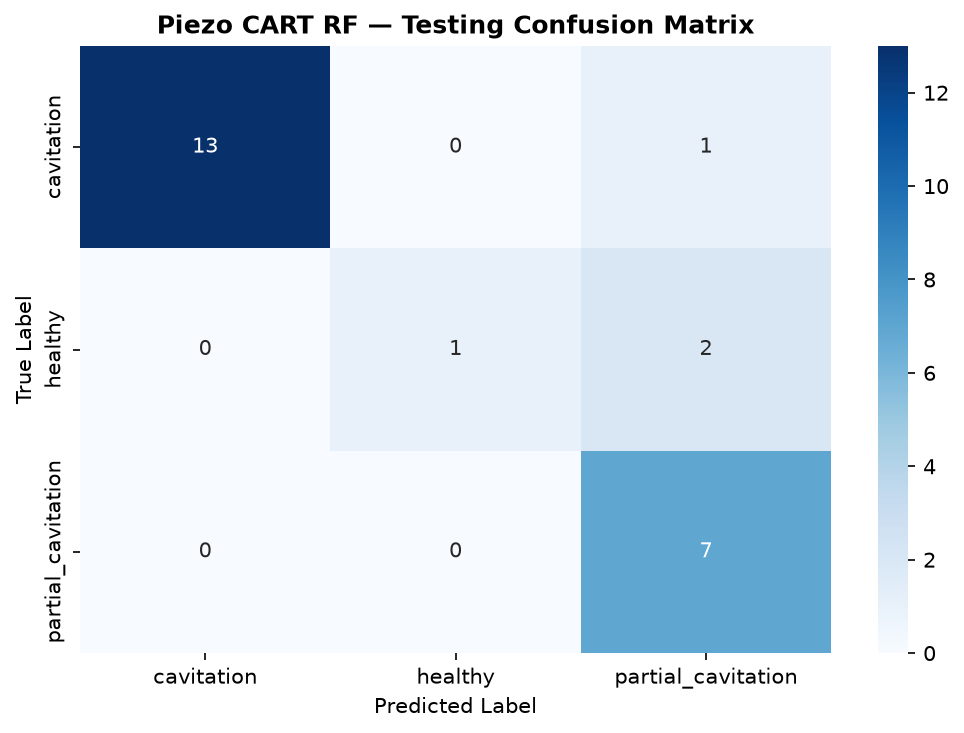

In [3]:
# Train Piezo CART Random Forest
rf_piezo = RandomForestClassifier(
    criterion="gini",
    max_depth=12,
    min_samples_leaf=5,
    ccp_alpha=0.001,
    n_estimators=100,
    random_state=42
)
rf_piezo.fit(X_tr_piezo_scaled, y_tr_piezo)

classes_piezo = list(rf_piezo.classes_)

# Test predictions & metrics
ts_preds_piezo = rf_piezo.predict(X_ts_piezo_scaled)
ts_probs_piezo = rf_piezo.predict_proba(X_ts_piezo_scaled)

ts_acc_piezo = accuracy_score(y_ts_piezo, ts_preds_piezo)
ts_prec_piezo = precision_score(y_ts_piezo, ts_preds_piezo, average='weighted', zero_division=0)
ts_rec_piezo = recall_score(y_ts_piezo, ts_preds_piezo, average='weighted', zero_division=0)
ts_f1_piezo = f1_score(y_ts_piezo, ts_preds_piezo, average='weighted', zero_division=0)
ts_auc_piezo = roc_auc_score(y_ts_piezo, ts_probs_piezo, multi_class='ovr', average='weighted')
cm_ts_piezo = confusion_matrix(y_ts_piezo, ts_preds_piezo, labels=classes_piezo)

print("=" * 60)
print(" PIEZO CART RF — TEST EVALUATION RESULTS (test_piezo.csv)")
print("=" * 60)
print(f"Testing Accuracy              : {ts_acc_piezo:.4f} ({ts_acc_piezo*100:.2f}%)")
print(f"Testing Precision (Weighted)  : {ts_prec_piezo:.4f}")
print(f"Testing Recall (Weighted)     : {ts_rec_piezo:.4f}")
print(f"Testing F1 Score (Weighted)   : {ts_f1_piezo:.4f}")
print(f"Testing ROC AUC (Weighted)    : {ts_auc_piezo:.4f}")
print("=" * 60)

# Plot Testing Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ts_piezo, annot=True, fmt='d', cmap='Blues', xticklabels=classes_piezo, yticklabels=classes_piezo)
plt.title('Piezo CART RF — Testing Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()


## 4. Weighted Testing Performance Summary Table


In [4]:
summary_weighted_table = pd.DataFrame({
    'Model': ['Audio CART RF', 'Piezo CART RF'],
    'Test Dataset': ['test_audio.csv', 'test_piezo.csv'],
    'Testing Accuracy': [f"{ts_acc_audio*100:.2f}% ({ts_acc_audio:.4f})", f"{ts_acc_piezo*100:.2f}% ({ts_acc_piezo:.4f})"],
    'Testing Precision (Weighted)': [f"{ts_prec_audio:.4f}", f"{ts_prec_piezo:.4f}"],
    'Testing Recall (Weighted)': [f"{ts_rec_audio:.4f}", f"{ts_rec_piezo:.4f}"],
    'Testing F1 Score (Weighted)': [f"{ts_f1_audio:.4f}", f"{ts_f1_piezo:.4f}"],
    'Testing ROC AUC (Weighted)': [f"{ts_auc_audio:.4f}", f"{ts_auc_piezo:.4f}"]
})

print("=== WEIGHTED TESTING EVALUATION SUMMARY ===")
print(summary_weighted_table.to_string(index=False))


=== WEIGHTED TESTING EVALUATION SUMMARY ===
        Model   Test Dataset Testing Accuracy Testing Precision (Weighted) Testing Recall (Weighted) Testing F1 Score (Weighted) Testing ROC AUC (Weighted)
Audio CART RF test_audio.csv 89.44% (0.8944)                      0.8993                  0.8944                     0.8948                     0.9795
Piezo CART RF test_piezo.csv 87.50% (0.8750)                      0.9125                  0.8750                     0.8644                     0.9623
